# Лабораторная работа №4: Линейные модели, SVM и деревья решений

**Цель работы:** Изучение и сравнение качества работы линейных моделей, метода опорных векторов (SVM) и деревьев решений на задаче классификации.

---

## 1. Описание задания
В данной работе решается задача классификации (злокачественная или доброкачественная опухоль) на основе набора данных **Breast Cancer**.
1. Проводится предобработка данных (масштабирование).
2. Обучаются три модели:
    * Логистическая регрессия (линейная модель).
    * Метод опорных векторов (SVM).
    * Дерево решений.
3. Оценка моделей проводится по двум метрикам: **Accuracy** (точность) и **F1-score**.
4. Проводится визуализация важности признаков и самого дерева решений.


## 2. Импорт библиотек и загрузка данных

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Загрузка датасета
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Размерность данных: {X.shape}")
print(f"Классы: {data.target_names}")
X.head()

Размерность данных: (569, 30)
Классы: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



## 3. Предобработка данных
Проверим наличие пропусков и выполним масштабирование, так как Логистическая регрессия и SVM чувствительны к разным диапазонам признаков.

In [2]:

# Проверка пропусков
print(f"Количество пропусков: {X.isnull().sum().sum()}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Количество пропусков: 0



## 4. Обучение моделей

### 4.1 Логистическая регрессия (Линейная модель)

In [3]:

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


### 4.2 SVM (Метод опорных векторов)

In [4]:

svm = SVC(kernel='linear') # Линейное ядро для сравнения с линейной моделью
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)


### 4.3 Дерево решений

In [5]:

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train) # Деревья не требуют масштабирования, используем сырые X_train
y_pred_dt = dt.predict(X_test)


## 5. Оценка качества и сравнение моделей

Будем использовать две метрики: **Accuracy** и **F1-score** (среднее гармоническое точности и полноты).

                 Model  Accuracy  F1-Score
0  Logistic Regression  0.973684  0.979021
1                  SVM  0.956140  0.964539
2        Decision Tree  0.947368  0.957746


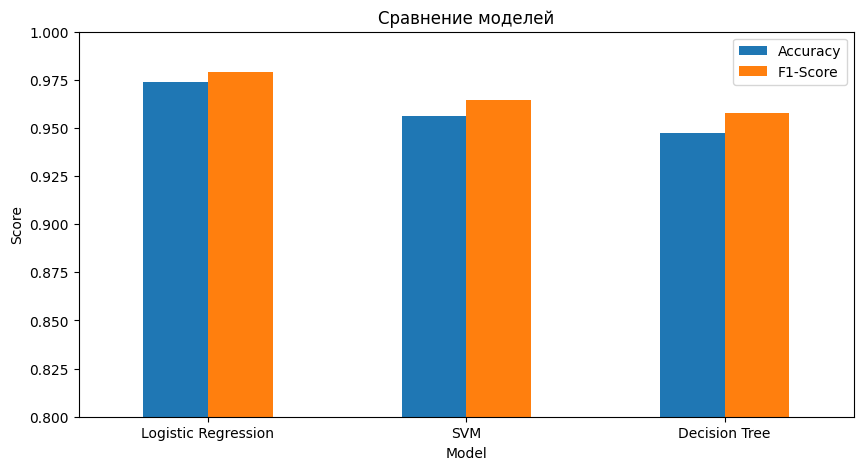

In [6]:
results = {
    "Model": ["Logistic Regression", "SVM", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt)
    ]
}

df_res = pd.DataFrame(results)
print(df_res)

# Визуализация сравнения
df_res.set_index('Model').plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.0))
plt.title('Сравнение моделей')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()


## 6. Важность признаков в дереве решений

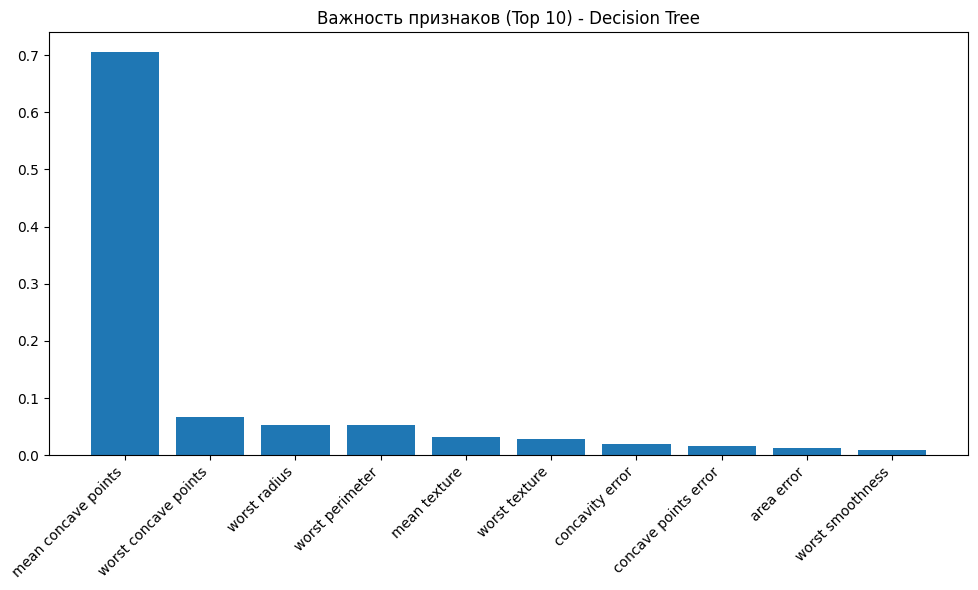

In [7]:
# Получение важности признаков
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

# Визуализация топ-10 признаков
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Top 10) - Decision Tree")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [X.columns[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. Визуализация дерева решений

Выведем структуру дерева графически и в текстовом виде.

Правила дерева решений:
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.18
|   |   |   |   |--- class: 0
|   |   |--- area error >  48.70
|   |   |   |--- texture error <= 1.93
|   |   |   |   |--- class: 1
|   |   |   |--- texture error >  1.93
|   |   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- worst texture <= 19.91
|   |   |   |--- clas...


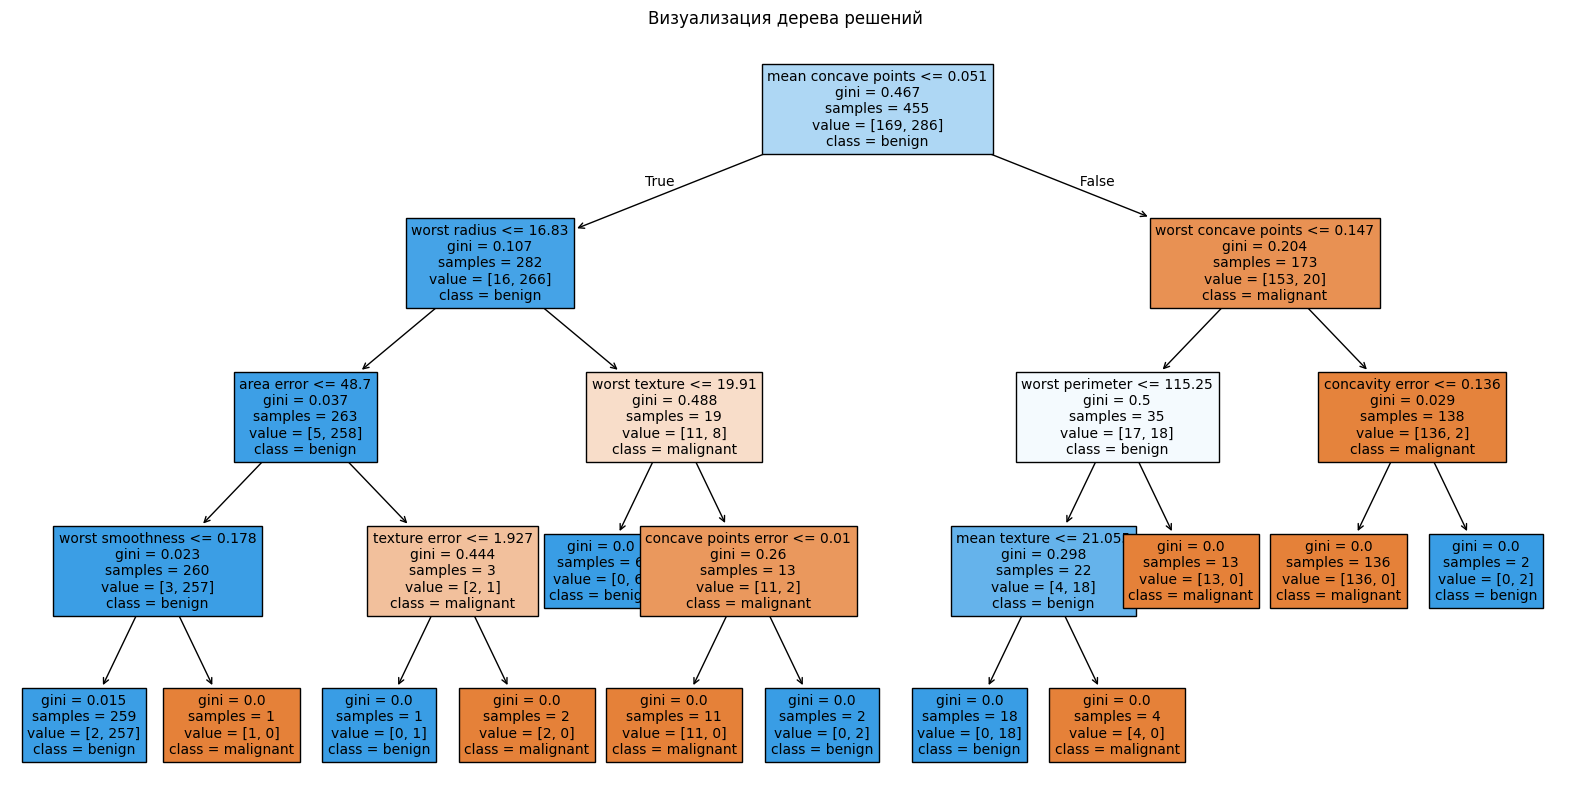

In [8]:
# Текстовый вывод правил
from sklearn.tree import export_text
tree_rules = export_text(dt, feature_names=list(X.columns))
print("Правила дерева решений:")
print(tree_rules[:500] + "...") # Ограничим вывод

# Графическая визуализация
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=data.target_names, filled=True, fontsize=10)
plt.title("Визуализация дерева решений")
plt.show()


## 8. Заключение

1. В ходе работы были обучены три типа классификаторов. 
2. **Логистическая регрессия и SVM** (с линейным ядром) показали схожие высокие результаты, так как данные в Breast Cancer часто линейно разделимы после масштабирования.
3. **Дерево решений** позволило наглядно интерпретировать логику принятия решений. По графику важности признаков видно, что `worst concave points` и `worst area` являются ключевыми для диагностики.
4. Метрики Accuracy и F1-score подтвердили высокую эффективность всех трех алгоритмов на данном наборе данных.
